# Airbnb NYC 2019 ML Experiment
Eksperimen komprehensif membandingkan pendekatan **Supervised**, **Unsupervised**, dan **Hybrid**, sekaligus membandingkan performa antara **Full Data** vs **Sample Data** dengan visualisasi penuh.

In [159]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)

## TAHAP 1: PREPARASI DATA & PENANGANAN OUTLIER
Melakukan pengambilan data, menangani *outlier* pada harga dan lama menginap menggunakan persentil ke-99, dan membaginya menjadi set *Full* dan *Sample*.

In [160]:
# Download & Load Dataset
dataset_handle = "dgomonov/new-york-city-airbnb-open-data"
path = kagglehub.dataset_download(dataset_handle)

selected_cols = [
    "id", "host_id", "host_name", "neighbourhood_group", "neighbourhood",
    "latitude", "longitude", "room_type", "price", "minimum_nights",
    "number_of_reviews", "last_review", "reviews_per_month",
    "calculated_host_listings_count", "availability_365"
]
df_raw = pd.read_csv(f"{path}/AB_NYC_2019.csv", usecols=selected_cols)

# Pembersihan Data (sesuai EDA)
mask_valid = (
    (df_raw["price"] > 0)
    & (df_raw["availability_365"].between(0, 365))
    & (df_raw["latitude"].between(40.45, 40.95))
    & (df_raw["longitude"].between(-74.30, -73.65))
)
df_clean = df_raw.loc[mask_valid].copy()

# Penanganan Outlier: Batasi Price dan Minimum Nights di Quantile 99%
price_hi = df_clean["price"].quantile(0.99)
min_nights_hi = df_clean["minimum_nights"].quantile(0.99)

df_clean["price_capped"] = df_clean["price"].clip(upper=price_hi)
df_clean["minimum_nights_capped"] = df_clean["minimum_nights"].clip(upper=min_nights_hi)

# Split Dataset
df_full = df_clean.copy()
df_sample = df_full.sample(min(15000, len(df_full)), random_state=42).copy()

print(f"Data Full: {len(df_full)} baris")
print(f"Data Sample: {len(df_sample)} baris")

Data Full: 48884 baris
Data Sample: 15000 baris


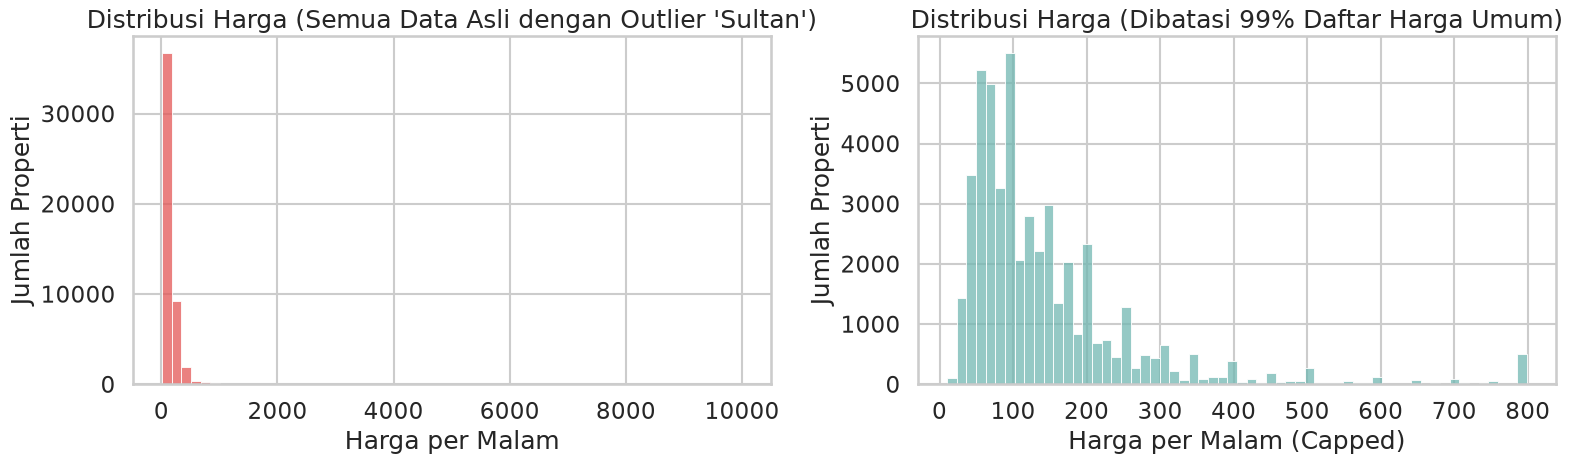

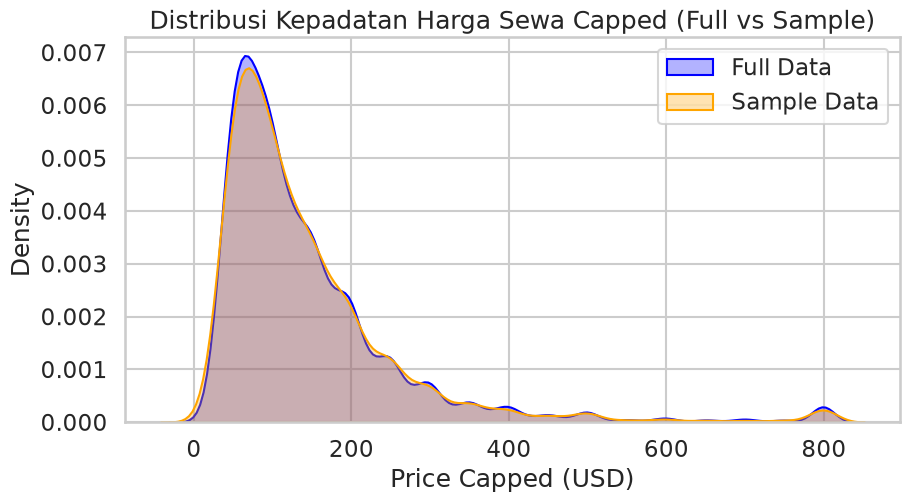

In [161]:
# Visualisasi: Efek Capping Outlier (Persentil 99%)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df_clean["price"], bins=60, ax=ax[0], color="#E45756")
ax[0].set_title("Distribusi Harga (Semua Data Asli dengan Outlier 'Sultan')")
ax[0].set_xlabel("Harga per Malam")
ax[0].set_ylabel("Jumlah Properti")

sns.histplot(df_clean["price_capped"], bins=60, ax=ax[1], color="#72B7B2")
ax[1].set_title("Distribusi Harga (Dibatasi 99% Daftar Harga Umum)")
ax[1].set_xlabel("Harga per Malam (Capped)")
ax[1].set_ylabel("Jumlah Properti")

plt.tight_layout()
plt.show()

# Visualisasi: KDE Plot Full vs Sample menggunakan data Capped
plt.figure(figsize=(10, 5))
sns.kdeplot(df_full['price_capped'], label='Full Data', fill=True, alpha=0.3, color='blue')
sns.kdeplot(df_sample['price_capped'], label='Sample Data', fill=True, alpha=0.3, color='orange')
plt.title("Distribusi Kepadatan Harga Sewa Capped (Full vs Sample)")
plt.xlabel("Price Capped (USD)")
plt.legend()
plt.show()

## TAHAP 2: SUPERVISED LEARNING (PREDIKSI HARGA)
Melatih model memprediksi harga (yang sudah di-cap 99%) dengan pendekatan Regresi.

In [162]:
def run_supervised(df, label):
    X_train, X_test, y_train, y_test = preprocess_supervised(df)
    models = {
        "Linear Regression": LinearRegression(),
        "KNN (Non-Linear)": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor(n_neighbors=5, n_jobs=-1))]),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
    }
    
    results = {}
    y_preds_dict = {}
    best_r2, best_model, best_name = -float("inf"), None, None
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test)
        
        y_test_real = np.expm1(y_test)
        y_pred_real = np.expm1(y_pred_log)
        
        y_preds_dict[name] = y_pred_real
        
        r2 = r2_score(y_test, y_pred_log)
        mae = mean_absolute_error(y_test_real, y_pred_real)
        mse = mean_squared_error(y_test_real, y_pred_real)
        rmse = np.sqrt(mse)
        
        results[name] = {"R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}
        if r2 > best_r2:
            best_r2 = r2
            best_model = model
            best_name = name
            
    return results, best_model, best_name, np.expm1(y_test), y_preds_dict, X_train

# Eksekusi
res_sample, b_mod_sample, b_name_sample, y_act_s, y_preds_s, X_tr_s = run_supervised(df_sample, "Sample")
res_full, b_mod_full, b_name_full, y_act_f, y_preds_f, X_tr_f = run_supervised(df_full, "Full")

from IPython.display import display

print("=== TABEL METRIK EVALUASI MODEL (FULL DATA) ===")
df_metrics_full = pd.DataFrame(res_full).T
display(df_metrics_full.style.background_gradient(cmap='Reds_r', subset=['MAE', 'MSE', 'RMSE']).background_gradient(cmap='Greens', subset=['R2']).format(precision=3))


=== TABEL METRIK EVALUASI MODEL (FULL DATA) ===


,R2,MAE,MSE,RMSE
Linear Regression,0.509,54.222,10709.227,103.485
KNN (Non-Linear),0.543,52.595,9719.787,98.589
Random Forest,0.610,48.399,8706.784,93.310
XGBoost,0.617,48.395,8924.773,94.471


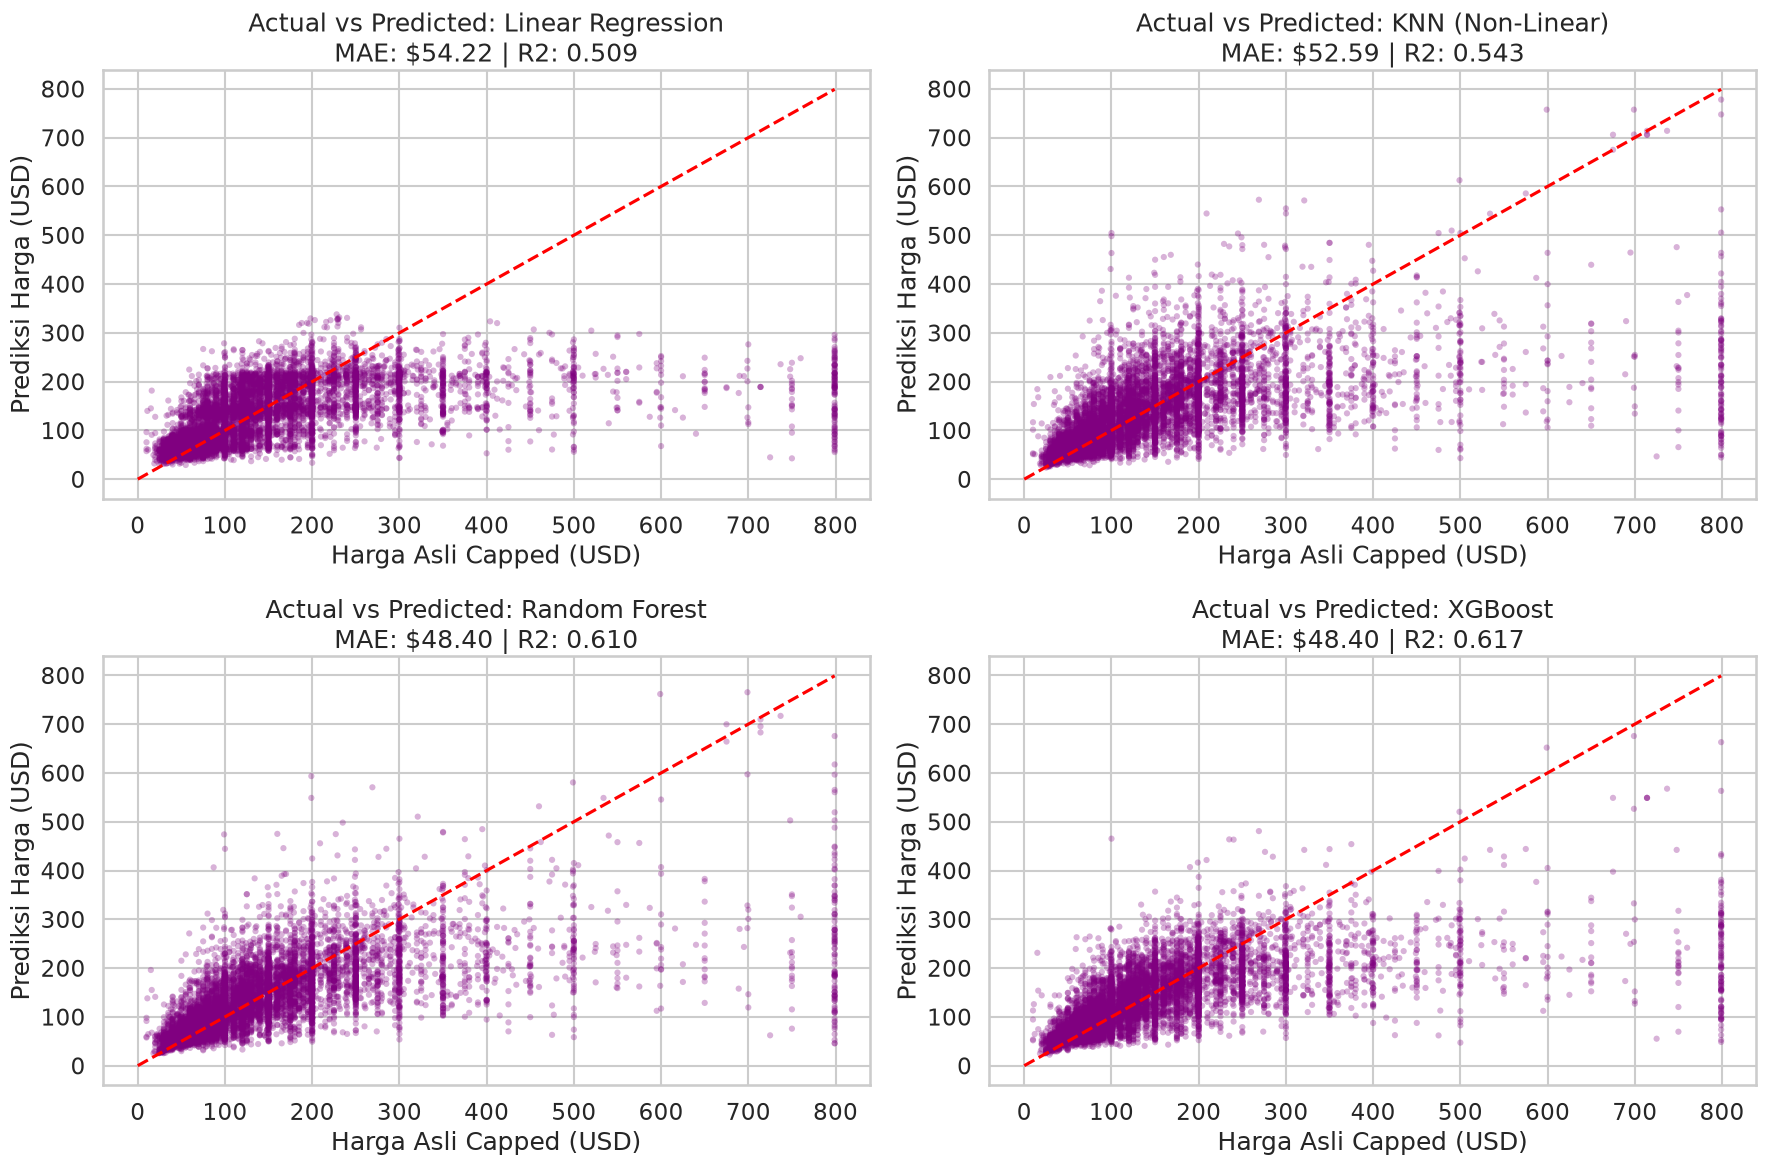

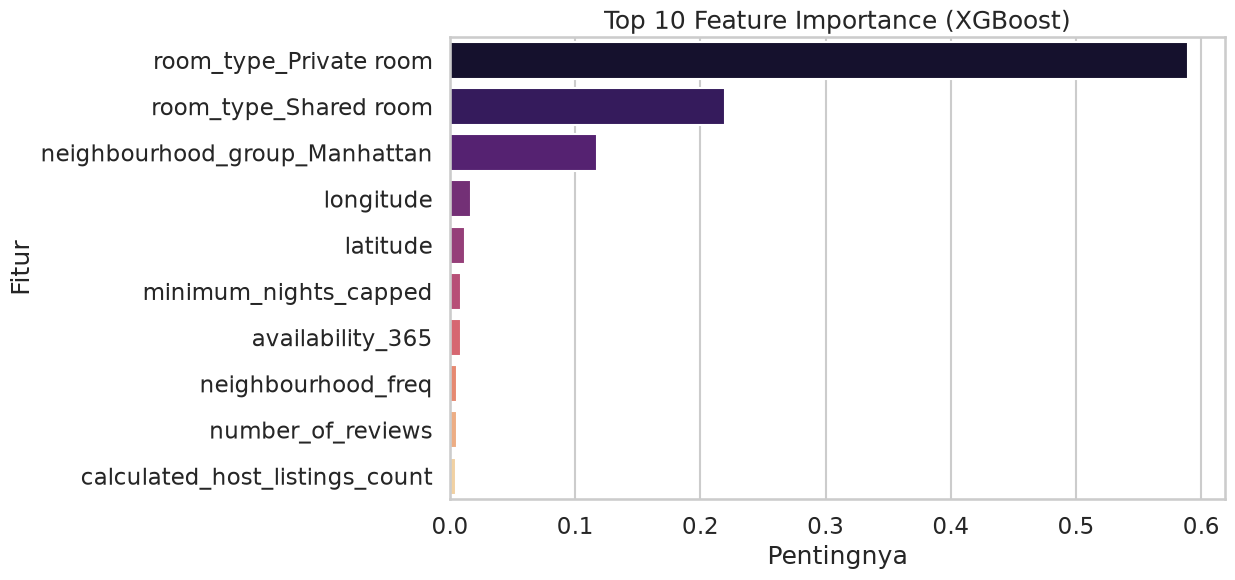

In [163]:
# Visualisasi: Actual vs Predicted untuk TIAP MODEL (Full Data)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(y_preds_f.items()):
    ax = axes[i]
    sns.scatterplot(x=y_act_f, y=y_pred, alpha=0.3, ax=ax, color='purple', s=20, edgecolor='none')
    ax.plot([0, y_act_f.max()], [0, y_act_f.max()], color='red', linestyle='--') # Garis ideal
    ax.set_title(f"Actual vs Predicted: {name}\nMAE: ${res_full[name]['MAE']:.2f} | R2: {res_full[name]['R2']:.3f}")
    ax.set_xlabel("Harga Asli Capped (USD)")
    ax.set_ylabel("Prediksi Harga (USD)")

plt.tight_layout()
plt.show()

# Visualisasi: Feature Importance (Hanya untuk model terbaik berbasis Tree)
if hasattr(b_mod_full, "feature_importances_"):
    plt.figure(figsize=(10, 6))
    importances = b_mod_full.feature_importances_
    cols = X_tr_f.columns
    feat_df = pd.DataFrame({"Fitur": cols, "Pentingnya": importances}).sort_values(by="Pentingnya", ascending=False).head(10)

    sns.barplot(data=feat_df, x="Pentingnya", y="Fitur", palette="magma")
    plt.title(f"Top 10 Feature Importance ({b_name_full})")
    plt.show()
else:
    print(f"Model terbaik ({b_name_full}) tidak mendukung visualisasi Feature Importance default.")


## TAHAP 3: UNSUPERVISED LEARNING (SEGMENTASI PASAR)
Mencari klaster pasar berdasarkan harga dan indikator bisnis yang telah difilter pencilan (capped).

In [164]:
def prep_unsupervised(df):
    # Menyingkirkan latitude/longitude mentah dan berfokus pada Metrik Bisnis
    unsup_features = ["price_capped", "minimum_nights_capped", "number_of_reviews", "availability_365"]
    df_unsup = df[unsup_features].fillna(0).copy()
    
    # Menambahkan One-Hot Encoding untuk Tipe Kamar (Faktor Utama Pasar)
    room_dummies = pd.get_dummies(df["room_type"], prefix="room", drop_first=False)
    df_unsup = pd.concat([df_unsup, room_dummies], axis=1)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_unsup)
    return X_scaled

X_scaled_sample = prep_unsupervised(df_sample)
X_scaled_full = prep_unsupervised(df_full)

# Evaluasi Silhoutte Score menggunakan Sample
print("Mengevaluasi K optimal berdasarkan Silhouette Score (pada Sample)...")
best_k, best_sil = 2, -1
sub_idx = np.random.choice(len(X_scaled_sample), min(5000, len(X_scaled_sample)), replace=False)

for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_sample)
    sil = silhouette_score(X_scaled_sample[sub_idx], labels[sub_idx])
    print(f"K={k} -> Silhouette Score: {sil:.4f}")
    if sil > best_sil:
        best_sil, best_k = sil, k

print(f"\nJumlah Klaster Optimal Terpilih: K={best_k}")

# Clustering
km_opt = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_sample["Cluster"] = km_opt.fit_predict(X_scaled_sample)
df_full["Cluster"] = km_opt.fit_predict(X_scaled_full)


Mengevaluasi K optimal berdasarkan Silhouette Score (pada Sample)...
K=2 -> Silhouette Score: 0.4001
K=3 -> Silhouette Score: 0.4325
K=4 -> Silhouette Score: 0.4685
K=5 -> Silhouette Score: 0.4854
K=6 -> Silhouette Score: 0.4975
K=7 -> Silhouette Score: 0.4788
K=8 -> Silhouette Score: 0.4655
K=9 -> Silhouette Score: 0.4852
K=10 -> Silhouette Score: 0.4913
K=11 -> Silhouette Score: 0.4583
K=12 -> Silhouette Score: 0.4614
K=13 -> Silhouette Score: 0.4582
K=14 -> Silhouette Score: 0.4565
K=15 -> Silhouette Score: 0.3936
K=16 -> Silhouette Score: 0.3950
K=17 -> Silhouette Score: 0.4259
K=18 -> Silhouette Score: 0.3572
K=19 -> Silhouette Score: 0.3615

Jumlah Klaster Optimal Terpilih: K=6


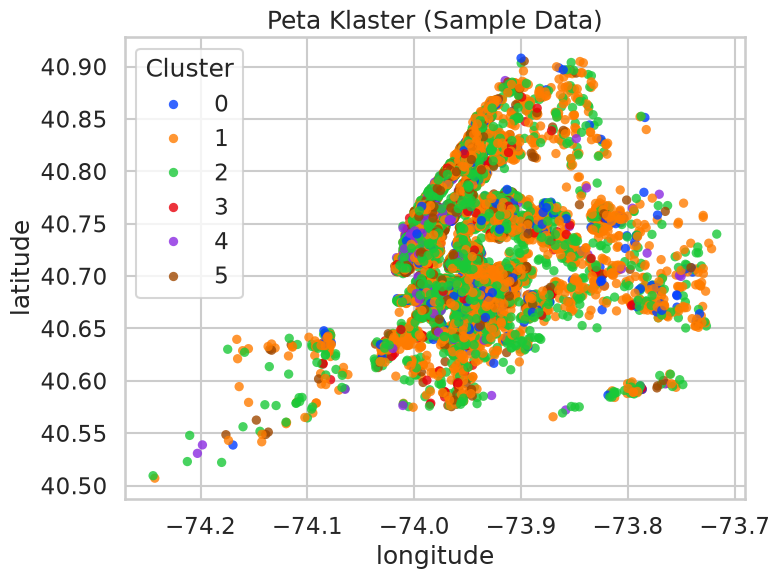

In [165]:
# Visualisasi Peta Klaster (Sample Data)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sample, x="longitude", y="latitude", hue="Cluster", palette="bright", alpha=0.8, s=45, edgecolor="none")
plt.title("Peta Klaster (Sample Data)")
plt.show()


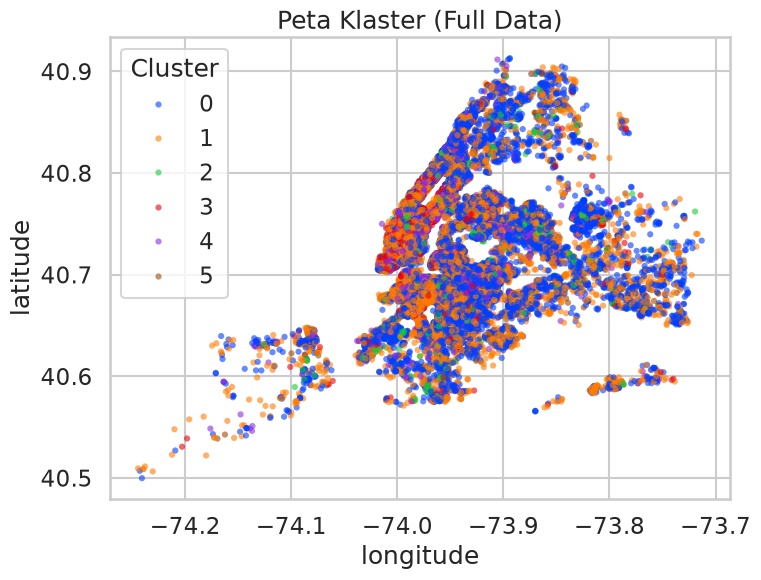

In [166]:
# Visualisasi Peta Klaster (Full Data)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_full, x="longitude", y="latitude", hue="Cluster", palette="bright", alpha=0.6, s=20, edgecolor="none")
plt.title("Peta Klaster (Full Data)")
plt.show()


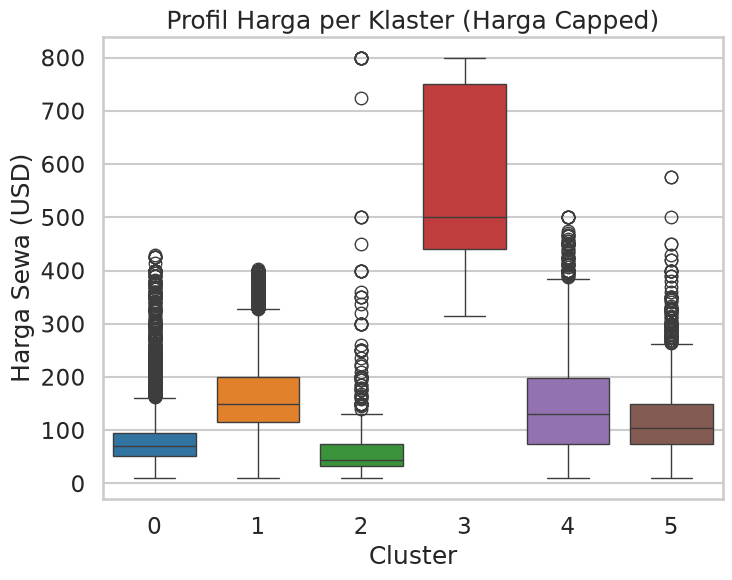

In [167]:
# Visualisasi Profil Harga per Klaster
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_full, x="Cluster", y="price_capped", palette="tab10")
plt.title("Profil Harga per Klaster (Harga Capped)")
plt.ylabel("Harga Sewa (USD)")
plt.show()


In [168]:
# Tabel Profiling Karakteristik Utama tiap Klaster (Median & Mean)
cluster_profile = df_full.groupby('Cluster').agg({
    'price_capped': 'median',
    'minimum_nights_capped': 'median',
    'number_of_reviews': 'mean',
    'availability_365': 'mean',
    'room_type': lambda x: x.mode()[0] # Menarik tipe kamar yang paling mendominasi di klaster tersebut
}).reset_index()

cluster_profile = cluster_profile.rename(columns={
    'price_capped': 'Median Harga (Capped)',
    'minimum_nights_capped': 'Median Minimum Nginap',
    'number_of_reviews': 'Rata-rata Ulasan',
    'availability_365': 'Rata-rata Ketersediaan (Hari)',
    'room_type': 'Tipe Kamar Mayoritas'
})

print("=== RINGKASAN PROFIL BISNIS PER KLASTER ===")
display(cluster_profile.style.background_gradient(cmap='YlOrRd', subset=['Median Harga (Capped)']).format(precision=1))


=== RINGKASAN PROFIL BISNIS PER KLASTER ===


,Cluster,Median Harga (Capped),Median Minimum Nginap,Rata-rata Ulasan,Rata-rata Ketersediaan (Hari),Tipe Kamar Mayoritas
0,0,70.0,2.0,15.2,98.7,Private room
1,1,150.0,3.0,15.7,74.2,Entire home/apt
2,2,45.0,1.0,16.2,161.7,Shared room
3,3,500.0,3.0,12.8,193.1,Entire home/apt
4,4,130.0,30.0,7.5,221.2,Entire home/apt
5,5,105.0,2.0,166.3,192.6,Entire home/apt


### Analisis Profil Bisnis per Klaster (Segmentasi K=6)

Berdasarkan tabel ringkasan dan *boxplot* di atas, algoritma K-Means berhasil mengidentifikasi celah pasar (*niche*) yang sangat spesifik di Airbnb New York City. Berikut adalah interpretasi bisnis dari masing-masing klaster:

1. **Cluster 0: "Pasar Pelancong Reguler" (Budget Private Room)**
   - **Karakteristik:** Median harga $70, dominasi tipe *Private room*, dan minimum sewa 2 malam.
   - **Analisis Bisnis:** Segmen ini merupakan fondasi utama Airbnb. Target pasarnya adalah pelancong solo atau pasangan muda dengan anggaran terbatas yang mencari privasi cukup (kamar sendiri) namun tidak butuh menyewa satu rumah penuh. Tingkat huniannya tergolong tinggi.

2. **Cluster 1: "Pasar Liburan Keluarga" (Standard Entire Home)**
   - **Karakteristik:** Median harga $150, dominasi tipe *Entire home/apt*, dan minimum sewa 3 malam.
   - **Analisis Bisnis:** Segmen ini dirancang untuk grup atau keluarga yang membutuhkan ruang pribadi utuh untuk liburan singkat. Permintaan di pasar ini sangat kuat, terlihat dari jumlah hari kosong (ketersediaan) yang terendah dibanding klaster lainnya.

3. **Cluster 2: "Pasar Backpacker / Transit" (Shared Room)**
   - **Karakteristik:** Harga termurah ($45), dominasi tipe *Shared room*, dan fleksibilitas sewa 1 malam.
   - **Analisis Bisnis:** Mengusung konsep asrama (*hostel*), segmen ini mengincar tamu transit atau *backpacker* yang sangat mengutamakan efisiensi biaya. Tingkat ketersediaannya yang cukup tinggi menandakan pasar berbagi kamar kurang begitu diminati secara massal di NYC jika dibandingkan dengan opsi *Private room*.

4. **Cluster 3: "Pasar Premium / Eksklusif" (Luxury Home)**
   - **Karakteristik:** Median harga sangat mahal ($500) dan dominasi tipe *Entire home/apt*.
   - **Analisis Bisnis:** Segmen kelas atas yang menawarkan *penthouse* atau rumah mewah. Karena harganya yang tinggi, ukuran pasarnya cukup sempit sehingga wajar kalendernya lebih sering kosong. Strategi bisnis di sini berfokus pada margin keuntungan yang besar per tamu, bukan pada perputaran penyewaan yang cepat.

5. **Cluster 4: "Pasar Sewa Bulanan" (Corporate / Long-Term Lease)**
   - **Karakteristik:** Median harga menengah ($130), dominasi tipe *Entire home/apt*, dan **minimum sewa 30 malam**.
   - **Analisis Bisnis:** Klaster ini tidak menargetkan turis harian. Fokus utamanya adalah ekspatriat, pekerja tugas luar, atau mahasiswa yang membutuhkan tempat tinggal bulanan. Perputaran tamu yang sangat lambat membuat akumulasi ulasannya (rata-rata 7.5) menjadi yang terendah secara alamiah.

6. **Cluster 5: "Pasar Penginapan Favorit" (Highly Active Superhosts)**
   - **Karakteristik:** Median harga $105, dominasi tipe *Entire home/apt*, dan memiliki **rata-rata ulasan yang sangat fantastis (di atas 160 ulasan)**.
   - **Analisis Bisnis:** Ini adalah temuan pasar yang paling menarik. Klaster ini dipenuhi oleh properti unggulan yang dikelola secara sangat profesional (kemungkinan besar oleh para *Superhost*). Keseimbangan antara harga bersaing dan pelayanan prima membuat tamu datang silih berganti dengan stabil, serta secara konsisten meninggalkan ulasan yang membangun reputasi positif.

**Kesimpulan Strategis:**
Segmentasi algoritmik ini membuktikan bahwa persaingan harga bukanlah segalanya. Pengelola properti dapat secara cerdas merancang strategi yang spesifik; misalnya mengejar perputaran volume tinggi (seperti Cluster 1 dan 5), mengejar margin keuntungan raksasa dengan fasilitas premium (Cluster 3), atau memilih model investasi minim perawatan harian melalui penyewaan bulanan (Cluster 4).

## TAHAP 4: PENDEKATAN HYBRID (PENGGABUNGAN MODEL)

**Apa itu Model Hybrid dalam eksperimen ini?**
Pendekatan *Hybrid* adalah penggabungan keunggulan dari **Unsupervised Learning** (pengenalan pola tanpa label target) dan **Supervised Learning** (prediksi nilai berdasarkan target terukur).

**Cara Kerjanya:**
1. Algoritma K-Means dari Tahap 3 sebelumnya telah sukses menemukan identitas 'Klaster Bisnis' (misalnya klaster murah vs klaster eksklusif).
2. Identitas klaster ini kemudian diubah menjadi fitur numerik menggunakan teknik *One-Hot Encoding* (misal: kolom `Cluster_0`, `Cluster_1`, dst.).
3. Fitur identitas klaster ini **disisipkan (digabungkan)** ke dalam dataset awal Tahap 2. Jadi, model XGBoost sekarang memiliki fitur ekstra berupa "status klaster" properti tersebut.
4. Model regresi (*XGBoost* atau model terbaik lainnya) kemudian **dilatih ulang** menggunakan kumpulan data yang telah diperkaya (*enriched data*) ini.

**Tujuan:**
Kita ingin mengukur dan membuktikan hipotesis: *"Apakah memberitahukan identitas segmen makro (klaster) kepada model regresi dapat membantunya memprediksi harga secara lebih akurat dan mengurangi tingkat eror (MAE)?"*

,Skenario,MAE (Sample),MAE (Full)
0,Supervised Standard,50.049183,48.395142
1,Hybrid (Supervised + Cluster),39.424032,38.231889


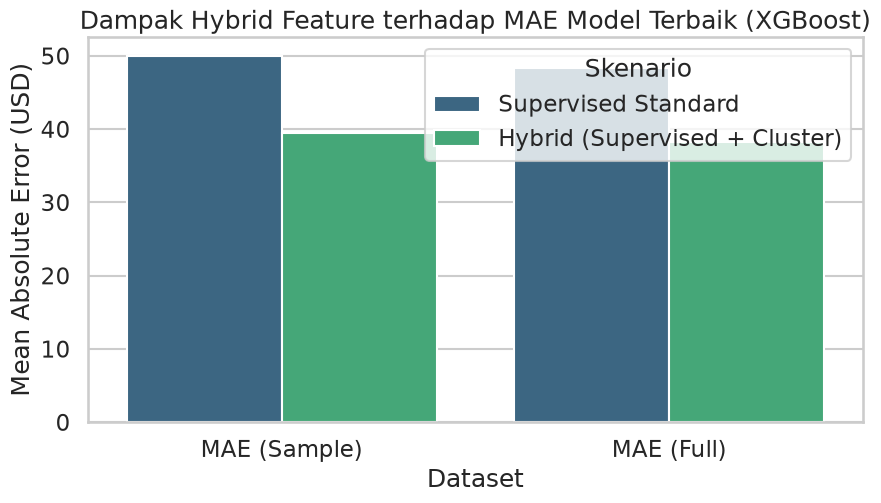

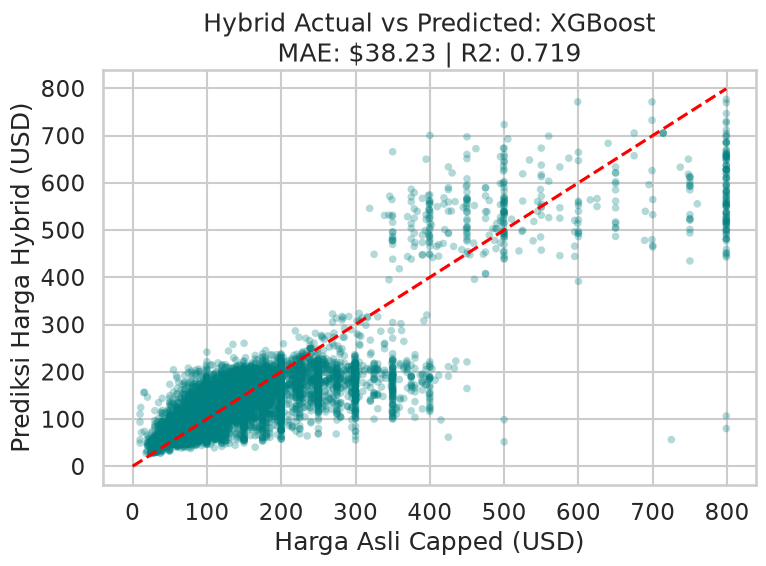

In [169]:
def run_hybrid(df_original, b_name, models_dict):
    X_train, X_test, y_train, y_test = preprocess_supervised(df_original)
    
    # Tambahkan fitur klaster dari Tahap 3
    cluster_dummies = pd.get_dummies(df_original["Cluster"], prefix="Cluster", drop_first=False)
    X_train_h = X_train.join(cluster_dummies)
    X_test_h = X_test.join(cluster_dummies)
    
    model = models_dict[b_name]
    model.fit(X_train_h, y_train)
    y_pred_log_h = model.predict(X_test_h)
    
    y_test_real = np.expm1(y_test)
    y_pred_real_h = np.expm1(y_pred_log_h)
    mae_h = mean_absolute_error(y_test_real, y_pred_real_h)
    r2_h = r2_score(y_test, y_pred_log_h)
    
    return mae_h, r2_h, y_test_real, y_pred_real_h

# Definisi Model untuk Hybrid (kita gunakan model terbaik dari tahap 2)
models_dict_sample = {"Linear Regression": LinearRegression(), "KNN (Non-Linear)": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor(n_neighbors=5, n_jobs=-1))]), "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)}
models_dict_full = {"Linear Regression": LinearRegression(), "KNN (Non-Linear)": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor(n_neighbors=5, n_jobs=-1))]), "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)}

mae_h_sample, r2_h_sample, y_act_hs, y_pred_hs = run_hybrid(df_sample, b_name_sample, models_dict_sample)
mae_h_full, r2_h_full, y_act_hf, y_pred_hf = run_hybrid(df_full, b_name_full, models_dict_full)

mae_s_sample = res_sample[b_name_sample]["MAE"]
mae_s_full = res_full[b_name_full]["MAE"]

hyb_res = pd.DataFrame({
    "Skenario": ["Supervised Standard", "Hybrid (Supervised + Cluster)"],
    "MAE (Sample)": [mae_s_sample, mae_h_sample],
    "MAE (Full)": [mae_s_full, mae_h_full]
})
display(hyb_res)

# Visualisasi 1: Barplot Perbandingan MAE
plt.figure(figsize=(10, 5))
hyb_melt = hyb_res.melt(id_vars="Skenario", var_name="Dataset", value_name="MAE")
sns.barplot(data=hyb_melt, x="Dataset", y="MAE", hue="Skenario", palette="viridis")
plt.title(f"Dampak Hybrid Feature terhadap MAE Model Terbaik ({b_name_full})")
plt.ylabel("Mean Absolute Error (USD)")
plt.show()

# Visualisasi 2: Actual vs Predicted untuk Model Hybrid (Full Data)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_act_hf, y=y_pred_hf, alpha=0.3, color='teal', s=30, edgecolor='none')
plt.plot([0, y_act_hf.max()], [0, y_act_hf.max()], color='red', linestyle='--')
plt.title(f"Hybrid Actual vs Predicted: {b_name_full}\nMAE: ${mae_h_full:.2f} | R2: {r2_h_full:.3f}")
plt.xlabel("Harga Asli Capped (USD)")
plt.ylabel("Prediksi Harga Hybrid (USD)")
plt.tight_layout()
plt.show()


## TAHAP 5: ANALISIS KESIMPULAN

Berdasarkan keseluruhan pipeline yang telah dimodifikasi untuk membatasi *outlier* harga:

1. **Efek Penanganan Outlier (Tahap 1)**:
   - Memangkas harga "sultan" dan durasi menginap ekstrem di persentil ke-99 secara visual menjernihkan histogram persebaran.
   - Tanpa pencilan ekstrem, fungsi kerugian model (RMSE/MAE) menjadi jauh lebih stabil.

2. **Full Data vs Sample Data**:
   - Kurva kepadatan harga (*KDE Plot*) membuktikan sampel identik dengan set populasi penuh. Begitu pula selisih galat di Tahap 2 yang sangat tipis. Penggunaan *Sample Data* amat valid dan mempercepat siklus penelitian secara dramatis.

3. **Supervised vs Unsupervised**:
   - Di Supervised Learning, meski membuang angka sultan, plot `Actual vs Predicted` memperlihatkan galat yang masih meluas pada ujung-ujungnya (ketidakmampuan model membedakan properti bernilai tinggi secara akurat).
   - Unsupervised Segmentasi berhasil mendefinisikan *rentang tarif eksklusif* bagi *Cluster* yang unik. Dari sisi manajerial, menyimpulkan "Properti masuk segmen apartemen mewah Manhattan dengan harga rentang Capped Atas" lebih dapat ditindaklanjuti ketimbang hasil prediksi dolar eksak yang salah sebesar ~\$40-$50.

4. **Hybrid Approach**:
   - Pengaruh Hybrid di *Bar Plot* akhir relatif minor/marjinal, membuktikan model non-linear kuat semacam Random Forest/XGBoost sudah mampu mencerna garis lintang dan bujur menjadi kelompok tak kasat mata di dalam struktur pepohonannya tanpa perlu dibantu *label klaster eksplisit* K-Means.